In [1]:
import pandas as pd

df = pd.read_csv("Travel details dataset.csv")

print("Dataset Loaded Successfully")

display(df.head())

print(df.info())

display(df.describe())

Dataset Loaded Successfully


,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200


<class 'pandas.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Trip ID               139 non-null    int64  
 1   Destination           137 non-null    str    
 2   Start date            137 non-null    str    
 3   End date              137 non-null    str    
 4   Duration (days)       137 non-null    float64
 5   Traveler name         137 non-null    str    
 6   Traveler age          137 non-null    float64
 7   Traveler gender       137 non-null    str    
 8   Traveler nationality  137 non-null    str    
 9   Accommodation type    137 non-null    str    
 10  Accommodation cost    137 non-null    str    
 11  Transportation type   136 non-null    str    
 12  Transportation cost   136 non-null    str    
dtypes: float64(2), int64(1), str(10)
memory usage: 14.2 KB
None


,Trip ID,Duration (days),Traveler age
count,139.000000,137.000000,137.000000
mean,70.000000,7.605839,33.175182
std,40.269923,1.601276,7.145441
min,1.000000,5.000000,20.000000
25%,35.500000,7.000000,28.000000
50%,70.000000,7.000000,31.000000
75%,104.500000,8.000000,38.000000
max,139.000000,14.000000,60.000000


In [2]:
print("\nMissing Values")

display(df.isnull().sum())


Missing Values


Trip ID                 0
Destination             2
Start date              2
End date                2
Duration (days)         2
Traveler name           2
Traveler age            2
Traveler gender         2
Traveler nationality    2
Accommodation type      2
Accommodation cost      2
Transportation type     3
Transportation cost     3
dtype: int64

In [3]:
# Remove duplicate rows

df = df.drop_duplicates()

# Fill numerical missing values with median
df["Duration (days)"] = df["Duration (days)"].fillna(
    df["Duration (days)"].median()
)

df["Traveler age"] = df["Traveler age"].fillna(
    df["Traveler age"].median()
)

# Fill categorical missing values with "Unknown"

categorical_columns = [
    "Destination",
    "Traveler gender",
    "Traveler nationality",
    "Accommodation type",
    "Transportation type"
]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

print("Duplicates Removed")
print("Missing Values Handled")

print(df.shape)

display(df.head())

Duplicates Removed
Missing Values Handled
(139, 13)


,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200


In [4]:
# Convert date columns

df["Start date"] = pd.to_datetime(
    df["Start date"],
    errors="coerce"
)

df["End date"] = pd.to_datetime(
    df["End date"],
    errors="coerce"
)

# Convert cost columns to numeric

df["Accommodation cost"] = pd.to_numeric(
    df["Accommodation cost"],
    errors="coerce"
)

df["Transportation cost"] = pd.to_numeric(
    df["Transportation cost"],
    errors="coerce"
)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Trip ID               139 non-null    int64         
 1   Destination           139 non-null    str           
 2   Start date            137 non-null    datetime64[us]
 3   End date              137 non-null    datetime64[us]
 4   Duration (days)       139 non-null    float64       
 5   Traveler name         137 non-null    str           
 6   Traveler age          139 non-null    float64       
 7   Traveler gender       139 non-null    str           
 8   Traveler nationality  139 non-null    str           
 9   Accommodation type    139 non-null    str           
 10  Accommodation cost    72 non-null     float64       
 11  Transportation type   139 non-null    str           
 12  Transportation cost   71 non-null     float64       
dtypes: datetime64[us](2), float64(4

In [5]:
df["Total Trip Cost"] = (
    df["Accommodation cost"] +
    df["Transportation cost"]
)

display(
    df[
        [
            "Trip ID",
            "Destination",
            "Duration (days)",
            "Accommodation cost",
            "Transportation cost",
            "Total Trip Cost"
        ]
    ].head()
)

,Trip ID,Destination,Duration (days),Accommodation cost,Transportation cost,Total Trip Cost
0,1,"London, UK",7.0,1200.0,600.0,1800.0
1,2,"Phuket, Thailand",5.0,800.0,500.0,1300.0
2,3,"Bali, Indonesia",7.0,1000.0,700.0,1700.0
3,4,"New York, USA",14.0,2000.0,1000.0,3000.0
4,5,"Tokyo, Japan",7.0,700.0,200.0,900.0


In [6]:
import sqlite3

conn = sqlite3.connect(":memory:")

df.to_sql(
    "travel_data",
    conn,
    index=False,
    if_exists="replace"
)

query = """

SELECT

Destination,

COUNT(*) AS Number_of_Trips,

SUM("Total Trip Cost") AS Total_Trip_Cost

FROM travel_data

GROUP BY Destination

ORDER BY Total_Trip_Cost DESC

LIMIT 10;

"""

result2 = pd.read_sql_query(query, conn)

display(result2)

conn.close()

,Destination,Number_of_Trips,Total_Trip_Cost
0,"Paris, France",7,14600.0
1,"Tokyo, Japan",7,14400.0
2,"New York City, USA",2,12500.0
3,"Sydney, Australia",3,11650.0
4,"Barcelona, Spain",4,10600.0
5,"Auckland, New Zealand",1,9500.0
6,Bali,7,8700.0
7,"Vancouver, Canada",2,8550.0
8,"Rio de Janeiro, Brazil",4,7900.0
9,"Rome, Italy",4,6800.0


In [7]:
print(result2.describe())

       Number_of_Trips  Total_Trip_Cost
count        10.000000         10.00000
mean          4.100000      10520.00000
std           2.233582       2704.74891
min           1.000000       6800.00000
25%           2.250000       8587.50000
50%           4.000000      10050.00000
75%           6.250000      12287.50000
max           7.000000      14600.00000


In [8]:
result2.to_csv(
    "top10_travel_destinations.csv",
    index=False
)

print("CSV Exported Successfully")

CSV Exported Successfully


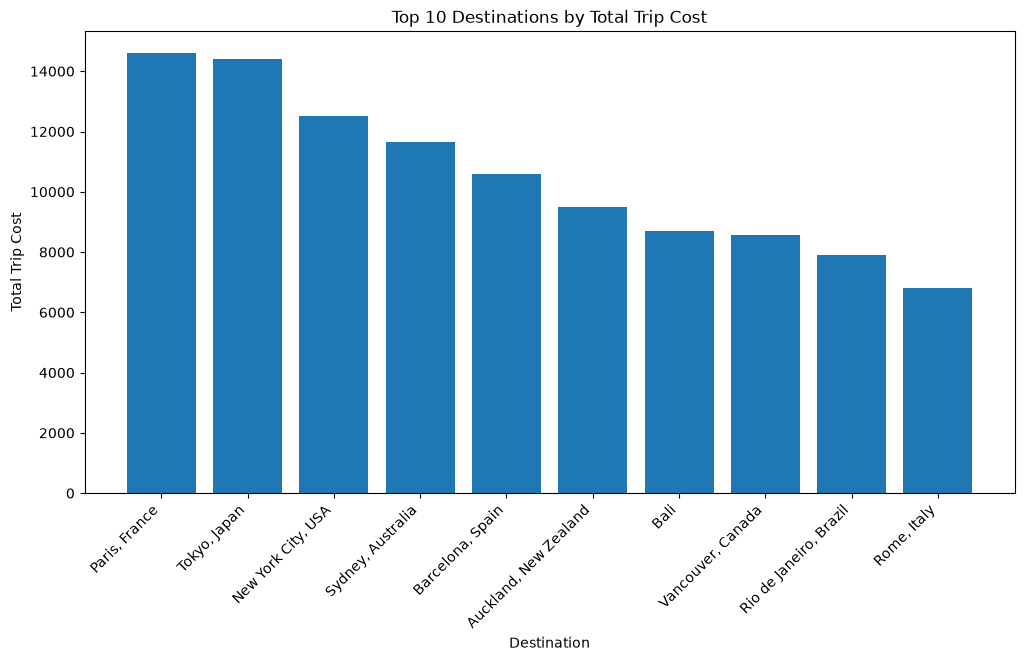

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    result2["Destination"],
    result2["Total_Trip_Cost"]
)

plt.xticks(rotation=45, ha="right")

plt.title("Top 10 Destinations by Total Trip Cost")

plt.xlabel("Destination")

plt.ylabel("Total Trip Cost")

plt.show()

In [10]:
years = df.iloc[:,2:]

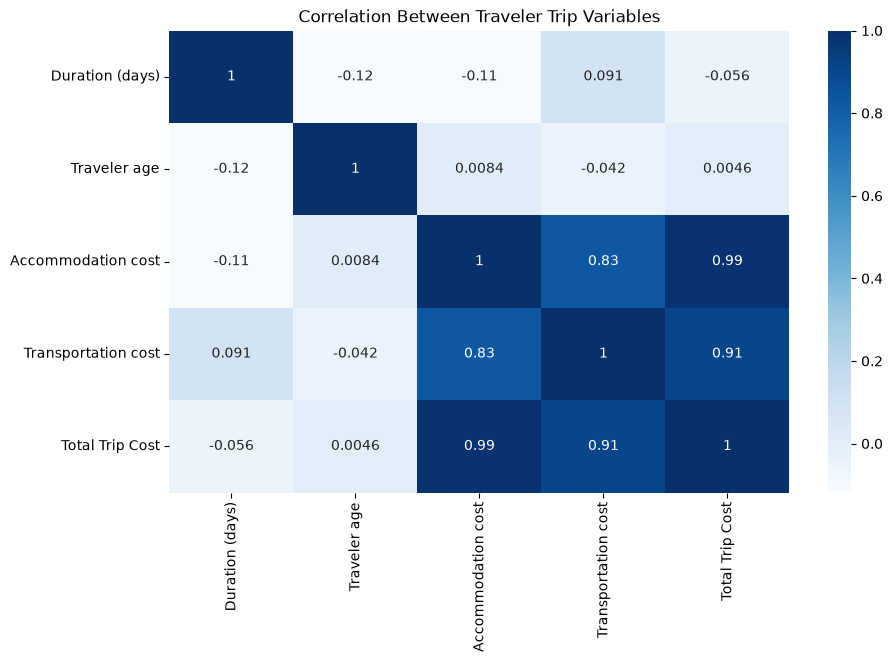

In [11]:
import seaborn as sns

numeric_columns = [
    "Duration (days)",
    "Traveler age",
    "Accommodation cost",
    "Transportation cost",
    "Total Trip Cost"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Between Traveler Trip Variables")

plt.show()

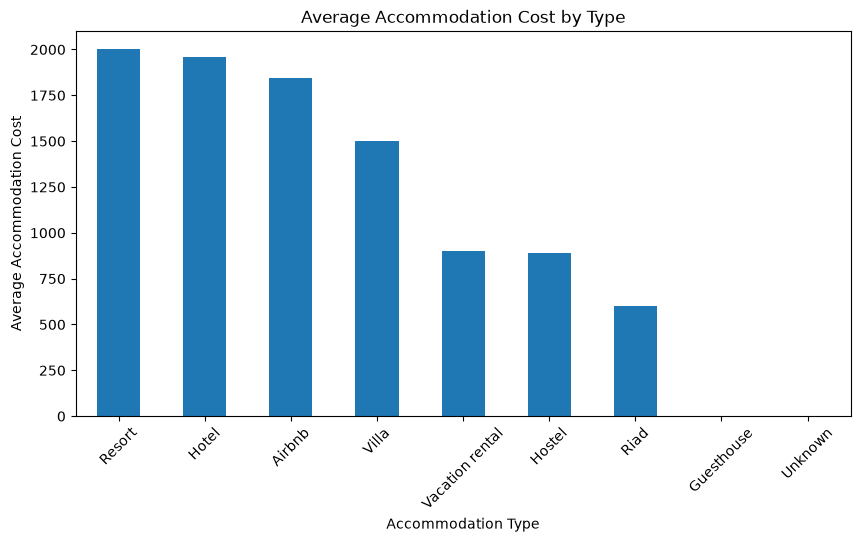

In [12]:
accommodation_cost = (
    df.groupby("Accommodation type")[
        "Accommodation cost"
    ].mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

accommodation_cost.plot(
    kind="bar"
)

plt.title("Average Accommodation Cost by Type")

plt.xlabel("Accommodation Type")

plt.ylabel("Average Accommodation Cost")

plt.xticks(rotation=45)

plt.show()

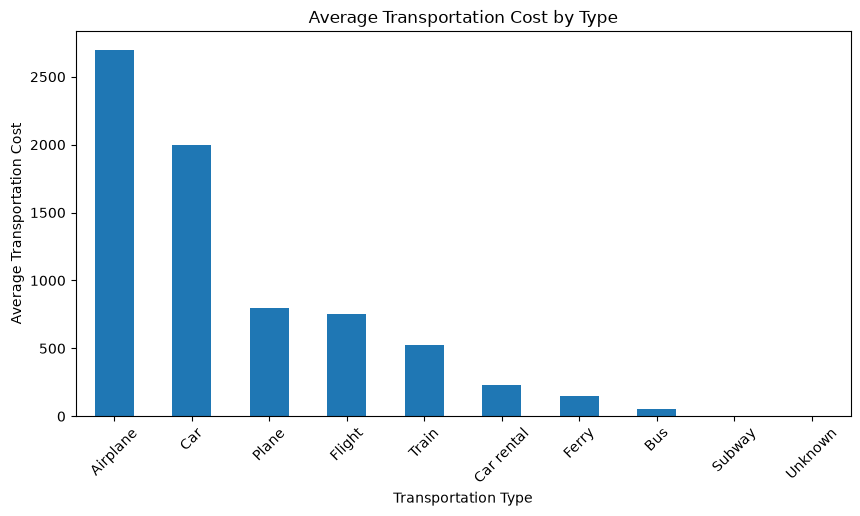

In [13]:
transportation_cost = (
    df.groupby("Transportation type")[
        "Transportation cost"
    ].mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

transportation_cost.plot(
    kind="bar"
)

plt.title("Average Transportation Cost by Type")

plt.xlabel("Transportation Type")

plt.ylabel("Average Transportation Cost")

plt.xticks(rotation=45)

plt.show()